In [4]:
# develope the som neural network
# realize all processes myself as code training
import numpy as np
import matplotlib.pyplot as plt

In [5]:
np.linalg.norm(np.array([[0, 0], [0, 1], [1, 0], [1, 1]])-np.array([3,3]),axis=1)

array([4.24264069, 3.60555128, 3.60555128, 2.82842712])

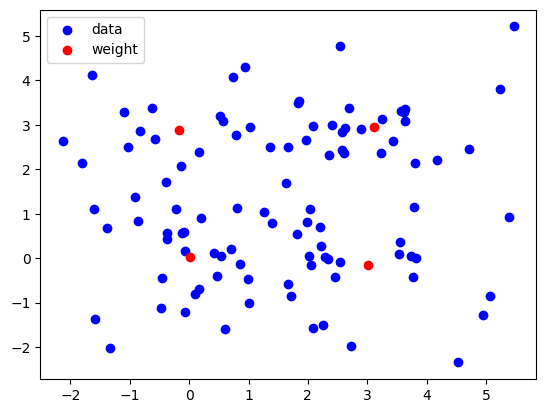

In [13]:
class SOMnn:
    # initialization
    def __init__(self,k,d):
        self.hidden_neuron=k
        self.feature_dim=d
        self.weight=np.random.rand(k,d)
    # competition
    def competition(self,x):
        distance=np.linalg.norm(self.weight-x,axis=1)
        winner_index=np.argmin(distance)
        return winner_index
    # updating
    def update(self,x,winner_index,learning_rate,sigma):
        for i in range(self.hidden_neuron):
            distance=np.linalg.norm(self.weight[i]-self.weight[winner_index])
            h=np.exp(-distance**2/(2*sigma**2))
            self.weight[i]+=learning_rate*h*(x-self.weight[i])
        
def main():
    # include data
    # create 4 different gaussian distribution data
    data=np.zeros((100,2))
    data[:25,:]=np.random.randn(25,2)+np.array([0,0])
    data[25:50,:]=np.random.randn(25,2)+np.array([0,3])
    data[50:75,:]=np.random.randn(25,2)+np.array([3,0])
    data[75:,:]=np.random.randn(25,2)+np.array([3,3]) 
    # begin building som nn
    ## 1. initialize the weight
    som=SOMnn(4,2)
    sigma0=1.0
    eta0=0.1
    # self-organizing
    sigma=sigma0
    eta=eta0
    itr=0
    while eta>0.01 and sigma>0.1:
        itr+=1
        ## 2. sampling
        x=data[np.random.randint(0,100)]
        ## 3. competition
        winner_index=som.competition(x)
        ## 4. updating
        sigma=sigma0*(1-itr/1000)
        eta=eta0*(1-itr/1000)
        som.update(x,winner_index,eta,sigma)
    # convergence phase
    eta=0.01
    for epoch in range(500*data.shape[0]):
        x=data[np.random.randint(0,100)]
        winner_index=som.competition(x)
        som.update(x,winner_index,eta,0.1)
    # end
    #visualization

    plt.scatter(data[:,0],data[:,1],c='blue',label='data')
    plt.scatter(som.weight[:,0],som.weight[:,1],c='red',label='weight')
    plt.legend()
    plt.show()  

if __name__=='__main__':
    main()


    

